# Logistic Regression Classification

## What it does
Logistic regression models the **probability of a class** using a linear combination of features:

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta^\top x)}}$$

The regularization parameter `C` (inverse of penalty strength) controls overfitting:
- **Small C** = strong regularization, simpler model
- **Large C** = weak regularization, closer to unpenalized logistic

## When to use it
- Binary or multiclass classification tasks
- You need an interpretable linear decision boundary
- High-dimensional features (use `penalty='l1'` for automatic feature selection)

## Penalties
| Penalty | Effect |
|---|---|
| `l2` (default) | Shrinks all coefficients — handles multicollinearity |
| `l1` | Zeros out some coefficients — automatic feature selection |

## Data format
A CSV or Parquet file with a numeric binary target (0/1). If your target is continuous,
set `BINARIZE_TARGET = True` and define a threshold to create the binary label.

## Configuration

Edit the values below to adapt this notebook to a new dataset.

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/FREDMD.csv',
    'DATE_COL':           'sasdate',
    # --- Target ---
    # Set BINARIZE_TARGET=True to threshold a continuous column into 0/1
    'TARGET_COL':         'INDPRO',
    'BINARIZE_TARGET':    True,
    'THRESHOLD':          0.0,       # y=1 if value > threshold (e.g. INDPRO growth > 0)
    # --- Time splits ---
    'TRAIN_FRAC':         0.6,
    'VAL_FRAC':           0.2,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- Logistic grid ---
    'C_GRID':             [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'PENALTY':            'l2',      # 'l1' requires solver='liblinear'
    'SOLVER':             'lbfgs',
    'MAX_ITER':           1000,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/FREDMD.csv
  DATE_COL: sasdate
  TARGET_COL: INDPRO
  BINARIZE_TARGET: True
  THRESHOLD: 0.0
  TRAIN_FRAC: 0.6
  VAL_FRAC: 0.2
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  C_GRID: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
  PENALTY: l2
  SOLVER: lbfgs
  MAX_ITER: 1000
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Build Target

In [2]:
import sys, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import load_csv, load_parquet, standardize_splits

if CONFIG['DATA_FILE'].endswith(('.pq', '.parquet')):
    df = load_parquet(CONFIG['DATA_FILE'])
else:
    df = load_csv(CONFIG['DATA_FILE'])

if CONFIG['DATE_COL'] in df.columns:
    df = df.drop(columns=[CONFIG['DATE_COL']])

print(f'Dataset shape : {df.shape}')
df.head()

Dataset shape : (2024, 140)


,date,RPI,W875RX1,DPCERA3M086SBEA,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,IPNCONGD,...,AAAFFM,BAAFFM,TWEXAFEGSMTHx,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,UMCSENTx,VIXCLSx
0,1855-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
y_raw = pd.to_numeric(df[CONFIG['TARGET_COL']], errors='coerce')
y = (y_raw > CONFIG['THRESHOLD']).astype(int) if CONFIG['BINARIZE_TARGET'] else y_raw.astype(int)

feature_cols = [c for c in df.columns
                if c != CONFIG['TARGET_COL'] and pd.api.types.is_numeric_dtype(df[c])]
X = df[feature_cols].fillna(CONFIG['MISSING_FILL_VALUE'])

valid = ~y.isna()
X, y = X[valid], y[valid]

print(f'Features      : {len(feature_cols)}')
print(f'Observations  : {len(y)}')
print(f'Class balance : {y.value_counts().to_dict()}')

Features      : 138
Observations  : 2024
Class balance : {0: 1262, 1: 762}


In [4]:
n       = len(y)
n_train = int(n * CONFIG['TRAIN_FRAC'])
n_val   = int(n * CONFIG['VAL_FRAC'])

X_train, y_train = X.iloc[:n_train],              y.iloc[:n_train]
X_val,   y_val   = X.iloc[n_train:n_train+n_val], y.iloc[n_train:n_train+n_val]
X_test,  y_test  = X.iloc[n_train+n_val:],        y.iloc[n_train+n_val:]

split_info = {'train_n_obs': len(y_train), 'val_n_obs': len(y_val), 'test_n_obs': len(y_test)}

print(f'Train  : {len(y_train):,} obs  (class 1: {y_train.mean()*100:.1f}%)')
print(f'Val    : {len(y_val):,} obs  (class 1: {y_val.mean()*100:.1f}%)')
print(f'Test   : {len(y_test):,} obs  (class 1: {y_test.mean()*100:.1f}%)')

Train  : 1,214 obs  (class 1: 20.3%)
Val    : 404 obs  (class 1: 64.1%)
Test   : 406 obs  (class 1: 63.1%)


## Step 2 — Standardize Features

In [5]:
if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')
else:
    print('Standardization skipped.')

Features standardized (fit on training data only).


## Step 3 — Grid Search over C

Best C selected by **validation accuracy**.

In [6]:
grid_results = []
for C in CONFIG['C_GRID']:
    model = LogisticRegression(C=C, penalty=CONFIG['PENALTY'],
                               solver=CONFIG['SOLVER'], max_iter=CONFIG['MAX_ITER'], random_state=42)
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    grid_results.append({'C': C, 'val_acc': val_acc, 'model': model})
    print(f'  C={C:>8.3f}  Val accuracy={val_acc*100:.2f}%')

best = max(grid_results, key=lambda r: r['val_acc'])
print(f"\nBest C={best['C']}  (Val accuracy={best['val_acc']*100:.2f}%)")

  C=   0.001  Val accuracy=66.58%
  C=   0.010  Val accuracy=80.69%
  C=   0.100  Val accuracy=81.19%
  C=   1.000  Val accuracy=80.20%
  C=  10.000  Val accuracy=80.45%
  C= 100.000  Val accuracy=80.69%

Best C=0.1  (Val accuracy=81.19%)


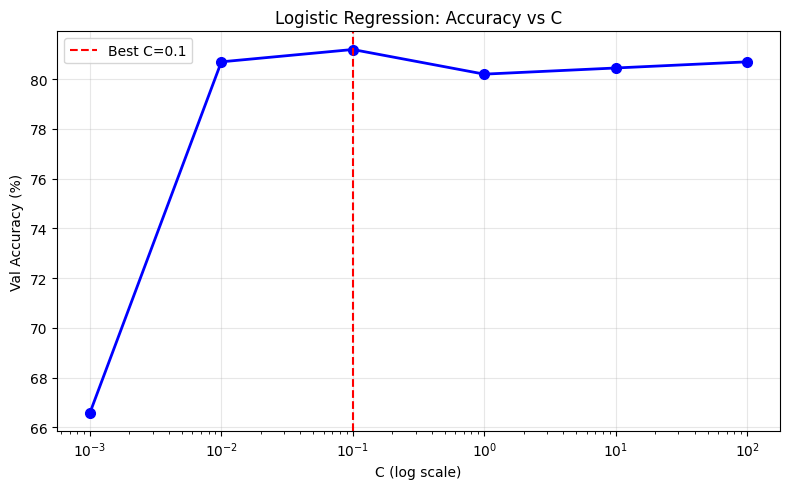

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx([r['C'] for r in grid_results], [r['val_acc']*100 for r in grid_results], 'b-o', linewidth=2, markersize=7)
ax.axvline(x=best['C'], color='red', linestyle='--', label=f"Best C={best['C']}")
ax.set(xlabel='C (log scale)', ylabel='Val Accuracy (%)', title='Logistic Regression: Accuracy vs C')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Step 4 — Final Evaluation on Test Set

In [8]:
m            = best['model']
y_pred_test  = m.predict(X_test)
y_prob_test  = m.predict_proba(X_test)[:, 1]
test_acc     = accuracy_score(y_test, y_pred_test)
test_auc     = roc_auc_score(y_test, y_prob_test)
cm           = confusion_matrix(y_test, y_pred_test)

print('LOGISTIC REGRESSION — TEST EVALUATION')
print('=' * 55)
print(f"  C              : {best['C']}")
print(f"  Penalty        : {CONFIG['PENALTY']}")
print()
print(f"  Train accuracy : {accuracy_score(y_train, m.predict(X_train))*100:.2f}%")
print(f"  Val accuracy   : {best['val_acc']*100:.2f}%")
print(f"  Test accuracy  : {test_acc*100:.2f}%")
print(f"  Test AUC-ROC   : {test_auc:.4f}")
print()
print(classification_report(y_test, y_pred_test))
print('Confusion Matrix:')
print(cm)

LOGISTIC REGRESSION — TEST EVALUATION
  C              : 0.1
  Penalty        : l2

  Train accuracy : 94.89%
  Val accuracy   : 81.19%
  Test accuracy  : 75.12%
  Test AUC-ROC   : 0.8768

              precision    recall  f1-score   support

           0       0.61      0.90      0.73       150
           1       0.92      0.66      0.77       256

    accuracy                           0.75       406
   macro avg       0.76      0.78      0.75       406
weighted avg       0.81      0.75      0.76       406

Confusion Matrix:
[[135  15]
 [ 86 170]]


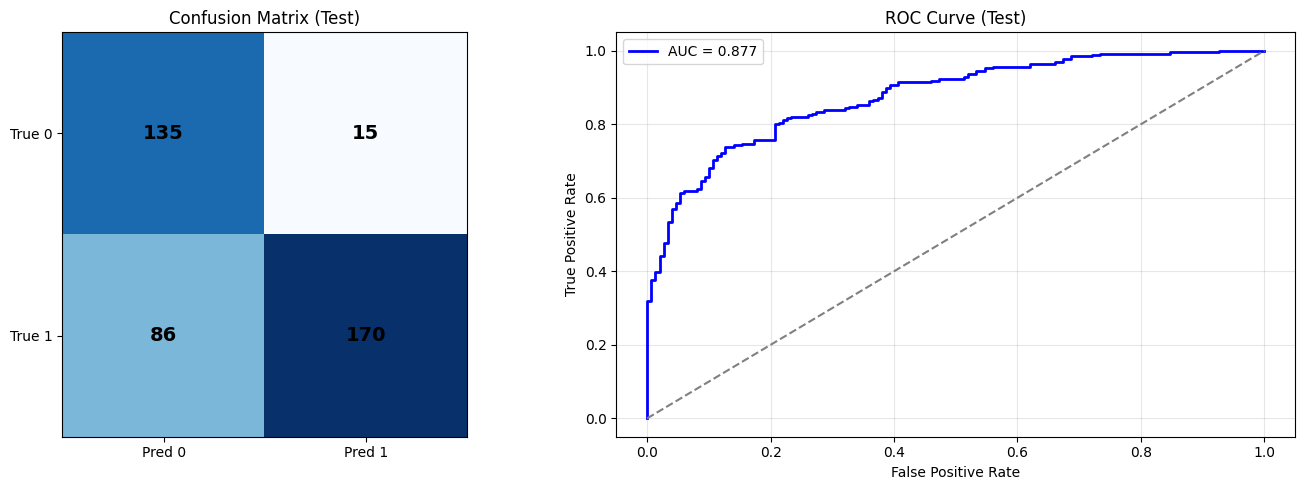

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
axes[0].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1']); axes[0].set_yticklabels(['True 0', 'True 1'])
axes[0].set_title('Confusion Matrix (Test)')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle='--')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve (Test)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Step 5 — Coefficient Analysis

Positive coefficients increase P(y=1); negative decrease it.

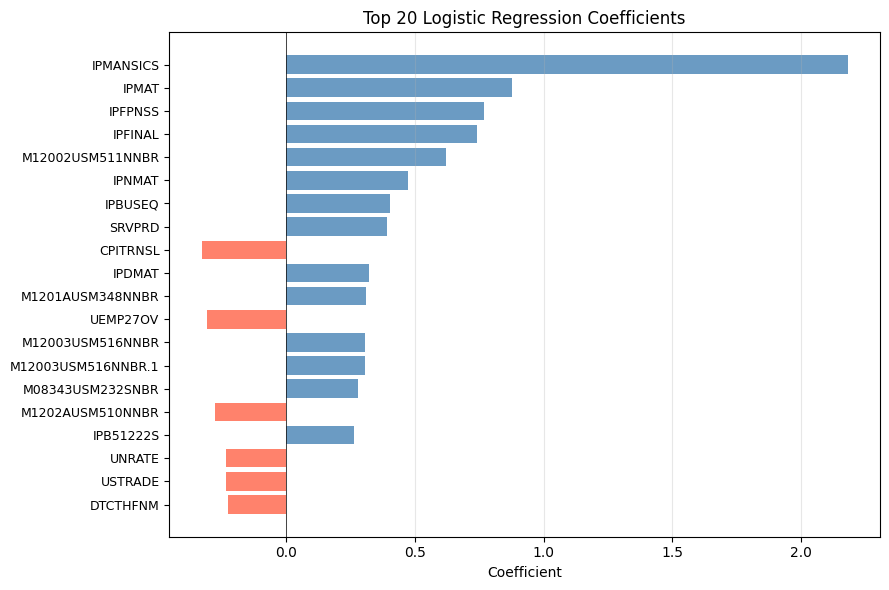

In [10]:
top_n   = 20
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': m.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in coef_df['coefficient']]
ax.barh(range(top_n), coef_df['coefficient'].values, color=colors, alpha=0.8)
ax.set_yticks(range(top_n)); ax.set_yticklabels(coef_df['feature'].values, fontsize=9)
ax.invert_yaxis(); ax.axvline(x=0, color='black', linewidth=0.5)
ax.set(xlabel='Coefficient', title=f'Top {top_n} Logistic Regression Coefficients')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Step 6 — Save Results

In [11]:
if CONFIG['SAVE_RESULTS']:
    os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)
    summary = {
        'model': 'Logistic Regression', 'penalty': CONFIG['PENALTY'], 'best_C': best['C'],
        'train_accuracy': float(accuracy_score(y_train, m.predict(X_train))),
        'val_accuracy': float(best['val_acc']),
        'test_accuracy': float(test_acc), 'test_auc_roc': float(test_auc),
        'n_features': len(feature_cols), 'standardized': CONFIG['STANDARDIZE'],
        **split_info, 'notebook': 'logistic_classification',
    }
    path = os.path.join(CONFIG['OUTPUT_DIR'], 'logistic_summary.csv')
    pd.DataFrame([summary]).to_csv(path, index=False)
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/logistic_summary.csv
